Comme on a dis lors de la séance 3, on souhaite réaliser HMM (Hidden Markov Model) pour trouver les états cachés en laissant l'algorithme les découvrir lui-même avec l'hypothèse qu'il a 3 états $S_t$ :
- Bull market : faible volatilité, rendements positifs stables
- Bear market / crise : très forte volatilité, krachs
- Crab market : marché incertain

Pour faire HMM, il faut utiliser l'hypothèse de Markov : $ P(S_t|S_{t-1},S_{t-2},...)=P(S_t|S_{t-1}) $, cela revient à dire que l'état de demain ne sera déterminé que par l'état d'aujourd'hui (grossièrement)

Pour que le modèle fonctionne on ne lui donne pas les 28 indicateurs car sinon il ferait de l'overfitting ou pire car certaines ne sont pas pertinentes. On lui donne donc un tenseur bi-dimensionnel : 
- la direction avec le rendement en log d'une action ou d'une moyenne d'actions liées
- le thermoètre avec l'indicateur Cheap_Fear_Index

In [2]:
from hmmlearn import hmm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# charger la data processed
data_filled = pd.read_csv('../data/processed/chip_chain_processed.csv')
data_daily_returns = pd.read_csv('../data/processed/chip_chain_daily_returns.csv')
data_log_returns = pd.read_csv('../data/processed/chip_chain_log_returns.csv')
data_indicators = pd.read_csv('../data/processed/chip_chain_custom_indicators.csv')
print(data_filled.shape)
print(data_daily_returns.shape)
print(data_log_returns.shape)
print(data_indicators.shape)

(3498, 17)
(3497, 17)
(3497, 17)
(3435, 28)


In [3]:
# On créer un tenseur bi-dimensionnel avec les rendements logarithmiques de NVDA et l'indice Chip_Fear_Index
data_log_returns_nvda_without_first_62days = data_log_returns['NVDA'][62:].values
X_train = np.column_stack([data_log_returns_nvda_without_first_62days, data_indicators['Chip_Fear_Index']])
X_train.shape

(3435, 2)

In [4]:
print(X_train[:5])

[[-0.01726897  0.33136398]
 [-0.0297333   0.33004501]
 [ 0.01698441  0.33226589]
 [-0.0008024   0.33138882]
 [ 0.00400494  0.33207685]]


La question qui se pose c'est comment faire pour avoir un model qui fonctionne sans les états ni le fonctionnement pour comprendre les états (car si l'on avait l'un on aurait l'autre mais là on veut l'un et l'autre avec seulement de la data). C'est pourquoi on utilise l'algorithme de Baum-Welch (EM) pour deviner cela de manière itérative : la matrice de transition A et les probabilités d'émission B

Nos observations ici sont continues (rendements et volatilité), on utilise donc pas un alphabet discret mais des distributions Gaussiennes (moyenne et matrice de covariance). Le modèle suppose : $$ X_t|S_t=k~N(\mu _k,\Sigma _k) $$
C'est-à-dire que chaque régime possède sa moyenne et sa covariance

On l'appelle aussi EM car : 
- étape E (expectation) : le model regarde avec ces paramètres actuels, quelle est la probabilité que chaque jour appartient à chaque état, il calcul $ P(S_t=k|X) $
- étape M (maximization) : le modèle met à jour les moyennes, les covariances et les probabilités de transition
- on répète les étapes jusqu'à convergence

Intuitivement on se dit :
- Bull market
    - rendement moyen positif
    - faible volatilité
- Bear market
    - rendement négatif
    - forte volatilité
- Crab market
    - rendement faible
    - volatilité moyenne

In [5]:
# Créer et entraîner le modèle HMM
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42) # covariance_type="full" permet d'avoir une matrice de covariance complète pour chaque composante
model.fit(X_train)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [6]:
# voir ce qu'il a appris
print("Transition matrix:")
print(model.transmat_)
print("\nMeans:")
print(model.means_)
print("\nCovariances:")
print(model.covars_)

Transition matrix:
[[9.52407841e-01 2.81956042e-02 1.93965550e-02]
 [2.19605355e-02 9.74718364e-01 3.32110038e-03]
 [3.22780301e-02 8.10920594e-24 9.67721970e-01]]

Means:
[[0.00199424 0.34679704]
 [0.00170205 0.25706181]
 [0.00199188 0.49816384]]

Covariances:
[[[6.20999714e-04 1.60264953e-05]
  [1.60264953e-05 9.46456418e-04]]

 [[3.32460466e-04 2.74609434e-05]
  [2.74609434e-05 8.67959818e-04]]

 [[1.80757072e-03 7.91566748e-05]
  [7.91566748e-05 1.32986405e-02]]]


Ensuite, on se demande quelle a été la suite d'état pour créé cela à partir de toutes nos observations. Pour cela on utilise Viterbi a qui on donne les anciennes données utilisées pour Baum-Welch mais avec le model qui a appris. Viterbi cherche : $ arg(max_{S_1,...S_T}(P(S_1, ..., S_T|X_1,...,X_T))) $, $X_1,...,X_T:$ les données utilisées pour Baum-Welch. Donc la meilleur trajectoire complète depuis le début jusqu'à la fin

In [7]:
hidden_states = model.predict(X_train)

On le stocke

In [8]:
data_state_nvda = pd.DataFrame({
    'Date': data_log_returns['Date'][62:],
    'NVDA_Log_Returns': data_log_returns['NVDA'][62:],
    'Chip_Fear_Index': data_indicators['Chip_Fear_Index'][62:],
    'Market Regime': hidden_states
})

On le visualise

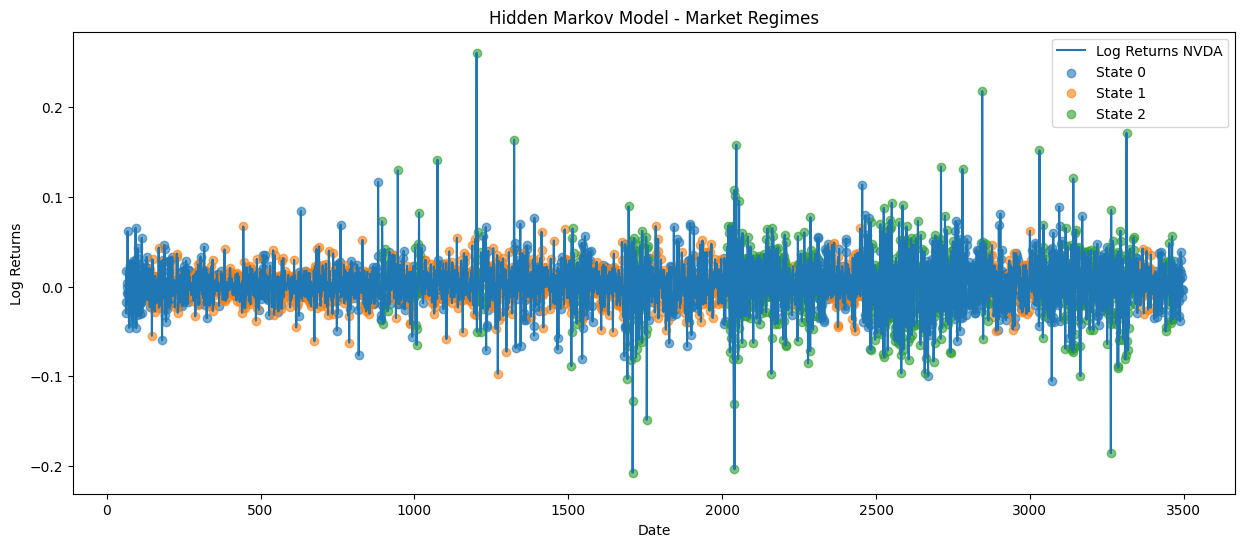

In [9]:
# Visualiser les régimes de marché
plt.figure(figsize=(15, 6))
plt.plot(data_log_returns['NVDA'][62:].index, data_log_returns['NVDA'][62:], label='Log Returns NVDA')
for i in range(model.n_components):
    state = (hidden_states == i)
    plt.scatter(data_log_returns['NVDA'][62:].index[state], data_log_returns['NVDA'][62:][state], label=f'State {i}', alpha=0.6)
plt.title('Hidden Markov Model - Market Regimes')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.show()

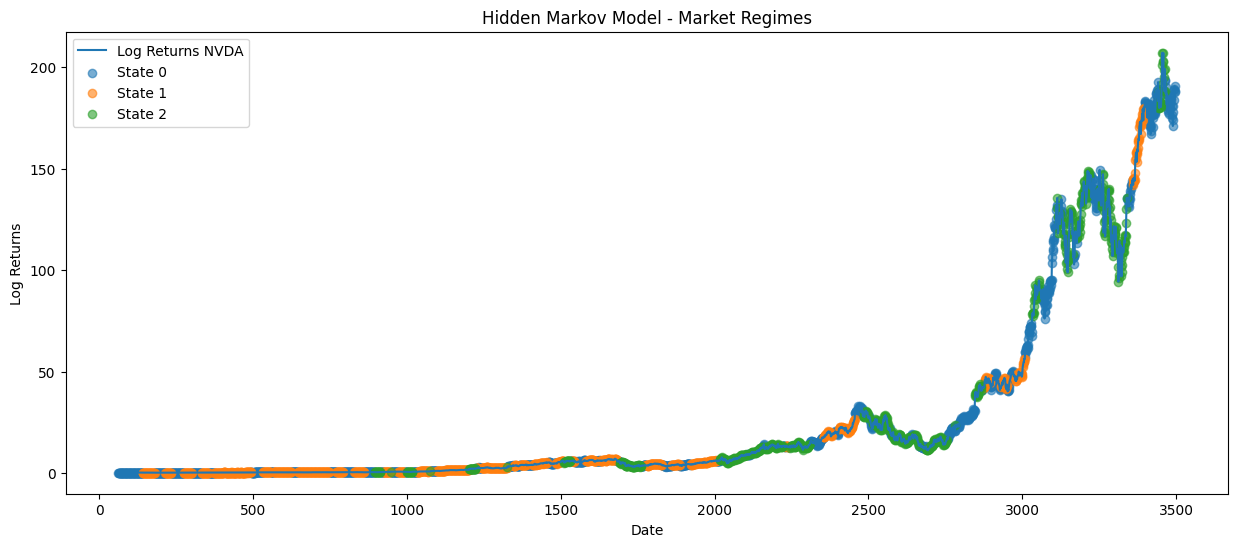

In [10]:
# Visualiser les régimes de marché
plt.figure(figsize=(15, 6))
plt.plot(data_filled['NVDA'][63:].index, data_filled['NVDA'][63:], label='Log Returns NVDA')
for i in range(model.n_components):
    state = (hidden_states == i)
    plt.scatter(data_filled['NVDA'][63:].index[state], data_filled['NVDA'][63:][state], label=f'State {i}', alpha=0.6)
plt.title('Hidden Markov Model - Market Regimes')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.show()

A partir de ces deux graphes si on reste sur notre hypothèse des 3 états qui suivent : 
- Bull market : faible volatilité, rendements positifs stables
- Bear market / crise : très forte volatilité, krachs
- Crab market : marché incertain

alors il semble que :
- Bull market = orange (état 1)
- Bear market / crise = vert (état 2)
- Crab market = bleu (état 0)

Vérifions cela plus précisément en faisant des calculs

In [11]:
# moyenne des rendements log de NVDA pour chaque état
data_state_nvda.groupby('Market Regime')[['NVDA_Log_Returns', 'Chip_Fear_Index']].mean()

,NVDA_Log_Returns,Chip_Fear_Index
Market Regime,,
0,0.001878,0.340762
1,0.001716,0.324435
2,0.002133,0.403323


On voit bien que l'on a ce que l'on souhaite en terme de peur mais le log_return parait bizarre, cela est du que l'on ai sur NVDA ça a beaucoup monté donc tous positives et plus pour ceux avec grandes peur car effet rebond aussi

Mais cela est trop spécifique à NVDA, on veut des états plus globaux pour cela, on travaille avec :
- La moyenne des 4 types d'actions
- Chip_Fear_Index
- TNX_Diff

Pas plus car sinon ça ferait trop (surtout avec covariance_type="full")

In [12]:
global_log_returns = data_log_returns.drop(columns=['Date', '^VIX', '^TNX'])
print(global_log_returns.shape)
global_log_returns_without_first_62days = global_log_returns[62:]
print(global_log_returns_without_first_62days.shape)
print(global_log_returns_without_first_62days[:5])
global_log_returns_mean = global_log_returns_without_first_62days.mean(axis=1)
print(global_log_returns_mean.shape)

(3497, 14)
(3435, 14)
     0981.HK      AAPL       AMD      ASML      AVGO       CGW     GOOGL  \
62 -0.012739 -0.007124 -0.029257 -0.015560 -0.041685 -0.009003  0.006173   
63  0.000000 -0.028893 -0.031531 -0.023186 -0.053252 -0.011489 -0.023263   
64 -0.012903  0.007455  0.000000  0.012067 -0.010488  0.004803  0.017568   
65  0.000000 -0.002286 -0.021113 -0.010833  0.007955 -0.002879  0.008588   
66 -0.039740  0.001759 -0.024479 -0.014699 -0.015330 -0.014034 -0.005958   

        INTC      MSFT      NVDA      PICK      TSLA       TSM       USO  
62 -0.014254 -0.001259 -0.017269 -0.011389 -0.044586 -0.025159 -0.026932  
63 -0.023381 -0.024866 -0.029733 -0.015539 -0.019599 -0.016699 -0.040468  
64 -0.005030 -0.010709  0.016984 -0.007635  0.019907 -0.001296 -0.006457  
65 -0.014148 -0.004906 -0.000802 -0.025572 -0.072806 -0.017005 -0.004870  
66 -0.006598  0.008489  0.004005  0.000000 -0.004316 -0.001981 -0.009538  
(3435,)


In [13]:
# calculer les états de manières plus général
print(data_log_returns['Date'][62:].shape)
print(global_log_returns_mean.shape)
print(data_indicators['Chip_Fear_Index'].shape)
print(data_indicators['TNX_Diff'].shape)
data_state = pd.DataFrame({  
    'Date': data_log_returns['Date'][62:].reset_index(drop=True),
    'Global_Log_Returns': global_log_returns_mean.reset_index(drop=True),
    'Chip_Fear_Index': data_indicators['Chip_Fear_Index'],
    'TNX_Diff': data_indicators['TNX_Diff'],
})
print(data_state.shape)
print(data_state.head())

(3435,)
(3435,)
(3435,)
(3435,)
(3435, 4)
         Date  Global_Log_Returns  Chip_Fear_Index  TNX_Diff
0  2012-05-03           -0.017860         0.331364    -0.034
1  2012-05-04           -0.024421         0.330045     0.002
2  2012-05-07            0.001733         0.332266    -0.044
3  2012-05-08           -0.011477         0.331389    -0.003
4  2012-05-09           -0.008744         0.332077    -0.040


In [14]:
# récupérer les données d'entraînement pour le modèle HMM
X_train_general = data_state[['Global_Log_Returns', 'Chip_Fear_Index', 'TNX_Diff']].values

# standardiser les données
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_general)

# baum-welch algorithm
model_general = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
model_general.fit(X_train_scaled)

# viterbi algorithm
hidden_states_general = model_general.predict(X_train_scaled)

On a standardiser la donnée car on a remarqué que sans on avait un problème de non convergence cela est dû au fait que les données n'avaient pas la même échelle le global_log_return était autour de 0.001 et le chip_fear_index autour de 0.3, ainsi le model à dû mal à calculer des variances avec d'aussi grosse différence d'échelle

In [15]:
# on stocke la data
data_state['Market_Regime'] = hidden_states_general

# calcul du rendement cumulé global
cumulative_returns = np.cumsum(data_state['Global_Log_Returns'])

c:\Dev\ChipChainReaction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


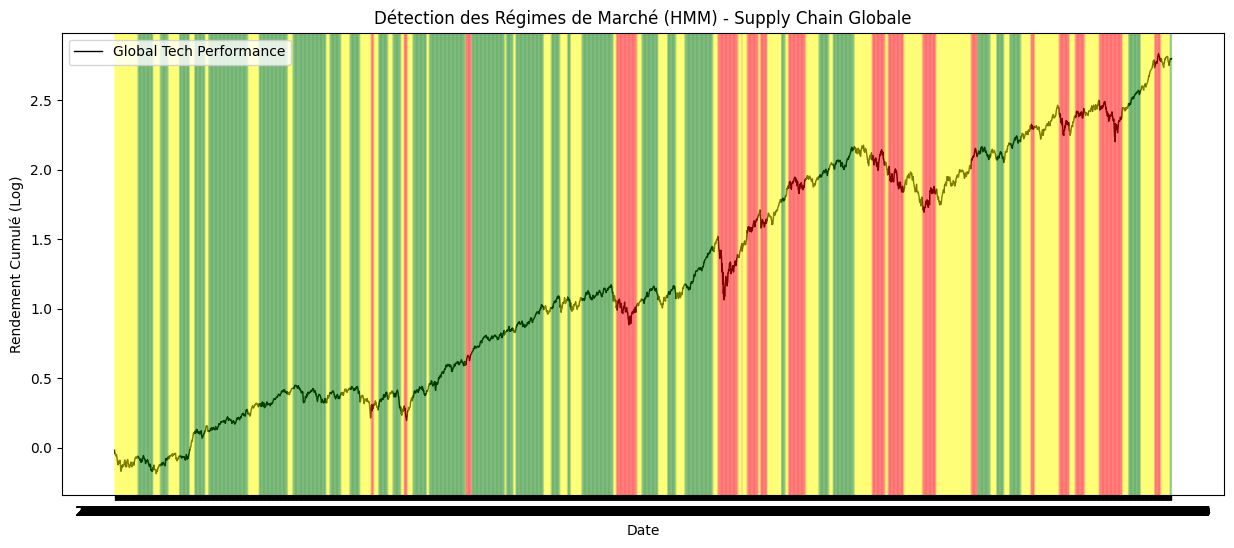

In [16]:
# Création du graphique
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(data_state['Date'], cumulative_returns, color='black', linewidth=1, label="Global Tech Performance")

colors = {0: 'red', 1: 'yellow', 2: 'green'}  # rouge pour crise, jaune pour transition et rebond, vert pour croissance

for regime in range(model_general.n_components):
    idx = data_state[data_state['Market_Regime'] == regime].index
    
    for i in idx:
        ax.axvline(data_state['Date'].iloc[i], color=colors[regime], alpha=0.1)

plt.title('Détection des Régimes de Marché (HMM) - Supply Chain Globale')
plt.xlabel('Date')
plt.ylabel('Rendement Cumulé (Log)')
plt.legend()
plt.show()

c:\Dev\ChipChainReaction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


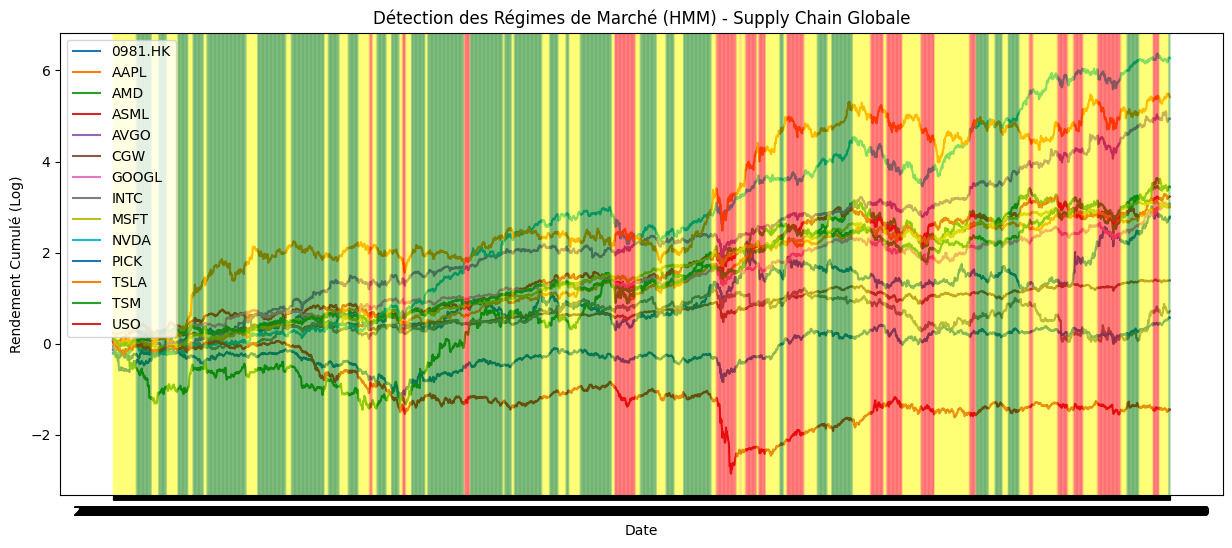


--- PROFIL DES RÉGIMES DE MARCHÉ ---
               Global_Log_Returns  Chip_Fear_Index  TNX_Diff
Market_Regime                                               
0                       -0.000337         0.530673 -0.000074
1                        0.001427         0.365307  0.001629
2                        0.000781         0.263242  0.000087


In [17]:
# Création du graphique mais avec toutes les rendements logs cumulés de tous les actifs
fig, ax = plt.subplots(figsize=(15, 6))

data_log_returns_cumsum = data_log_returns.drop(columns=['Date', '^VIX', '^TNX']).cumsum()
for column in data_log_returns_cumsum.columns:
    ax.plot(data_log_returns['Date'][62:], data_log_returns_cumsum[column][62:], label=column)

colors = {0: 'red', 1: 'yellow', 2: 'green'}  # rouge pour crise, jaune pour transition et rebond, vert pour croissance

for regime in range(model_general.n_components):
    idx = data_state[data_state['Market_Regime'] == regime].index

    for i in idx:
        ax.axvline(data_state['Date'].iloc[i], color=colors[regime], alpha=0.1)

plt.title('Détection des Régimes de Marché (HMM) - Supply Chain Globale')
plt.xlabel('Date')
plt.ylabel('Rendement Cumulé (Log)')
plt.legend()
plt.show()

# Affichage du profil des états pour comprendre qui est qui :
profil = data_state.groupby('Market_Regime')[['Global_Log_Returns', 'Chip_Fear_Index', 'TNX_Diff']].mean()
print("\n--- PROFIL DES RÉGIMES DE MARCHÉ ---")
print(profil)

In [18]:
print("Matrice de transition:")
print(model_general.transmat_)

print("\nMeans:")
print(model_general.means_)

print("\nCovariances:")
print(model_general.covars_)

Matrice de transition:
[[9.70779975e-01 2.92200247e-02 1.95004341e-41]
 [1.48737324e-02 9.59406783e-01 2.57194847e-02]
 [4.47874046e-09 2.03585900e-02 9.79641406e-01]]

Means:
[[-0.07404103  1.56730892 -0.0156548 ]
 [ 0.03972859  0.13339134  0.01625495]
 [-0.00166501 -0.76002961 -0.00676321]]

Covariances:
[[[ 2.66109422e+00  1.13799609e-01 -9.35798011e-02]
  [ 1.13799609e-01  1.10688944e+00 -1.96337516e-02]
  [-9.35798011e-02 -1.96337516e-02  1.52388251e+00]]

 [[ 8.43720352e-01  2.14157567e-02 -1.49098367e-02]
  [ 2.14157567e-02  9.56505811e-02  7.60435412e-03]
  [-1.49098367e-02  7.60435412e-03  1.06067857e+00]]

 [[ 4.33884606e-01  1.50988977e-03 -3.11814196e-02]
  [ 1.50988977e-03  8.10038372e-02  5.10093439e-03]
  [-3.11814196e-02  5.10093439e-03  7.32477829e-01]]]


On voit que le changement de paradigme change autour de l'arrivée de l'IA, on n'est plus dans un bull market mais dans un marché très stressé en très forte hausse

In [19]:
print("Globalement", data_state['Market_Regime'].value_counts())
print("\nAvant l'arrivée de l'IA et Covid", data_state['Market_Regime'][data_state['Date'] < '2020-03-01'].value_counts())
print("\nAprès l'arrivée de l'IA et Covid", data_state['Market_Regime'][data_state['Date'] >= '2020-03-01'].value_counts())

Globalement Market_Regime
2    1531
1    1273
0     631
Name: count, dtype: int64

Avant l'arrivée de l'IA et Covid Market_Regime
2    1275
1     576
0     117
Name: count, dtype: int64

Après l'arrivée de l'IA et Covid Market_Regime
1    697
0    514
2    256
Name: count, dtype: int64


On stocke la data des états

In [20]:
# On stocke la data avec les logs rendements et en plus on ajoute les régimes de marchés généraux et de NVDA
data_state_to_save = data_log_returns.copy()
data_state_to_save = data_state_to_save[62:].reset_index(drop=True)
print(data_state_to_save.shape)
data_state_to_save['Market_Regime_General'] = data_state['Market_Regime'].reset_index(drop=True)
# mais pour NVDA 1=>2, 2=>0, 0=>1 comme ça on garde la même logique que pour le modèle général (0=crise, 1=transition, 2=croissance)
data_state_to_save['Market_Regime_NVDA'] = data_state_nvda['Market Regime'].replace({0: 1, 1: 2, 2: 0}).reset_index(drop=True)
print(data_state['Market_Regime'].shape)
print(data_state_nvda['Market Regime'].shape)

data_state_to_save.to_csv('../data/processed/chip_chain_market_regimes.csv', index=False)

# on fait de même mais pour les rendements simples
data_simple_returns_to_save = data_daily_returns.copy()
data_simple_returns_to_save = data_simple_returns_to_save[62:].reset_index(drop=True)
data_simple_returns_to_save['Market_Regime_General'] = data_state['Market_Regime'].reset_index(drop=True)
data_simple_returns_to_save['Market_Regime_NVDA'] = data_state_nvda['Market Regime'].replace({0: 1, 1: 2, 2: 0}).reset_index(drop=True)
data_simple_returns_to_save.to_csv('../data/processed/chip_chain_market_regimes_simple_returns.csv', index=False)

(3435, 17)
(3435,)
(3435,)


On regarde pour finir les différences entre les deux modèles avec une matrice de corrélation

In [21]:
# On regarde les ressemblances entre les deux modèles de régimes de marché (NVDA vs Global)
contingency_table = pd.crosstab(data_state_to_save['Market_Regime_General'], data_state_to_save['Market_Regime_NVDA'])
print("--- TABLE DE CONTINGENCE ENTRE LES RÉGIMES GÉNÉRAUX ET NVDA ---")
print(contingency_table)

print("\nDifférence de comptages", data_state_to_save['Market_Regime_General'].value_counts() - data_state_to_save['Market_Regime_NVDA'].value_counts())

--- TABLE DE CONTINGENCE ENTRE LES RÉGIMES GÉNÉRAUX ET NVDA ---
Market_Regime_NVDA       0     1     2
Market_Regime_General                 
0                      631     0     0
1                      223  1046     4
2                        3   213  1315

Différence de comptages Market_Regime_General
2    212
1     14
0   -226
Name: count, dtype: int64


On voit que lorsque :
- le marché général est en crise Nvidia l'est tout le temps
- le marché général est en croissance stable, Nvidia est souvent très stable mais parfois en transition
- le marché général est en transition/rebond, Nvidia a souvent le même état mais parfois est en crise

Par rapport au marchés général pour les chips, Nvidia est plus souvent en crise, moins souvent stable et assez aligné avec l'état de transition (juste en différence du nombre de chaque état). Ce qui est logique car NVDA est plus volatile que la moyenne du marché